# Football Match Outcome Classification

**Machine Learning Coursework — Homework 2**

Pipeline overview:

Raw data → clean missing values → scale/encode/transform features → train ML model → make prediction

## uploading the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer

## reading the data

In [ ]:
soccer_df = pd.read_csv("data/student_version2.csv", low_memory=False)

In [4]:
soccer_df.shape

(110938, 190)

In [5]:
soccer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110938 entries, 0 to 110937
Columns: 190 entries, match_id to away_club_recent_competition_code_10
dtypes: float64(162), int64(2), object(26)
memory usage: 160.8+ MB


In [6]:
soccer_df.describe()

,match_id,competition_code,home_manager_id,away_manager_id,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,home_club_recent_played_at_home_4,home_club_recent_played_at_home_5,home_club_recent_played_at_home_6,...,away_club_recent_competition_code_1,away_club_recent_competition_code_2,away_club_recent_competition_code_3,away_club_recent_competition_code_4,away_club_recent_competition_code_5,away_club_recent_competition_code_6,away_club_recent_competition_code_7,away_club_recent_competition_code_8,away_club_recent_competition_code_9,away_club_recent_competition_code_10
count,1.109380e+05,110938.000000,8.921700e+04,8.912300e+04,109779.000000,108487.000000,107165.000000,105837.000000,104461.000000,103042.000000,...,109712.000000,108345.000000,106904.000000,105422.000000,103938.000000,102512.000000,101071.000000,99643.000000,98176.000000,96722.000000
mean,1.519875e+07,910.457012,1.287134e+07,1.291552e+07,0.306944,0.567801,0.466141,0.519469,0.487857,0.507288,...,901.986200,894.389137,886.368012,878.243611,869.450297,861.901455,853.435338,844.673223,837.678200,829.177374
std,2.536393e+06,549.120985,1.578479e+07,1.580344e+07,0.461228,0.495384,0.498855,0.499623,0.499855,0.499949,...,545.826707,542.247411,538.497274,534.864981,531.170701,527.338931,524.217968,520.954647,517.647869,514.900676
min,1.142829e+07,2.000000,2.000000e+00,2.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,1.200038e+07,444.000000,4.596120e+05,4.595650e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,438.000000,432.000000,426.000000,420.000000,417.000000,408.000000,399.000000,391.500000,387.000000,387.000000
50%,1.675988e+07,947.000000,1.552728e+06,1.552806e+06,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,944.000000,935.000000,906.500000,899.000000,884.000000,881.000000,860.000000,830.000000,821.000000,806.000000
75%,1.724230e+07,1293.000000,3.243116e+07,3.279539e+07,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1286.000000,1283.000000,1279.000000,1274.000000,1270.000000,1267.000000,1265.000000,1263.000000,1261.000000,1255.000000
max,1.805384e+07,2039.000000,3.756849e+07,3.756847e+07,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2039.000000,2039.000000,2039.000000,2039.000000,2039.000000,2039.000000,2039.000000,2039.000000,2028.000000,2025.000000


In [7]:
soccer_df.head(5)

,match_id,match_result,home_club,away_club,fixture_date,competition,competition_code,cup_game,home_manager_id,away_manager_id,...,away_club_recent_competition_code_1,away_club_recent_competition_code_2,away_club_recent_competition_code_3,away_club_recent_competition_code_4,away_club_recent_competition_code_5,away_club_recent_competition_code_6,away_club_recent_competition_code_7,away_club_recent_competition_code_8,away_club_recent_competition_code_9,away_club_recent_competition_code_10
0,11906497,away,Newell's Old Boys,River Plate,2019-12-01 00:45:00,Superliga,636,False,468196.0,468200.0,...,1122.0,642.0,636.0,636.0,636.0,1122.0,636.0,642.0,636.0,1122.0
1,11984383,home,Real Estelí,Deportivo Las Sabanas,2019-12-01 01:00:00,Primera Division,752,False,516788.0,22169161.0,...,752.0,752.0,752.0,752.0,752.0,752.0,752.0,752.0,752.0,752.0
2,11983301,draw,UPNFM,Marathón,2019-12-01 01:00:00,Liga Nacional,734,False,2510608.0,456313.0,...,734.0,734.0,734.0,734.0,734.0,734.0,734.0,734.0,734.0,734.0
3,11983471,away,León,Morelia,2019-12-01 01:00:00,Liga MX,743,False,1552508.0,465797.0,...,743.0,743.0,743.0,743.0,743.0,743.0,743.0,743.0,746.0,743.0
4,11883005,home,Cobán Imperial,Iztapa,2019-12-01 01:00:00,Liga Nacional,705,False,429958.0,426870.0,...,705.0,705.0,705.0,705.0,705.0,705.0,705.0,705.0,705.0,705.0


In [8]:
dtype_table = soccer_df.dtypes.to_frame("dtype")
dtype_table

,dtype
match_id,int64
match_result,object
home_club,object
away_club,object
fixture_date,object
...,...
away_club_recent_competition_code_6,float64
away_club_recent_competition_code_7,float64
away_club_recent_competition_code_8,float64
away_club_recent_competition_code_9,float64


In [9]:
soccer_df["match_result"].value_counts(ascending=False)

match_result
home    48113
away    35174
draw    27651
Name: count, dtype: int64

In [10]:
soccer_df["match_result"].value_counts(normalize=True).mul(100) # No missing values

match_result
home    43.369269
away    31.705998
draw    24.924733
Name: proportion, dtype: float64

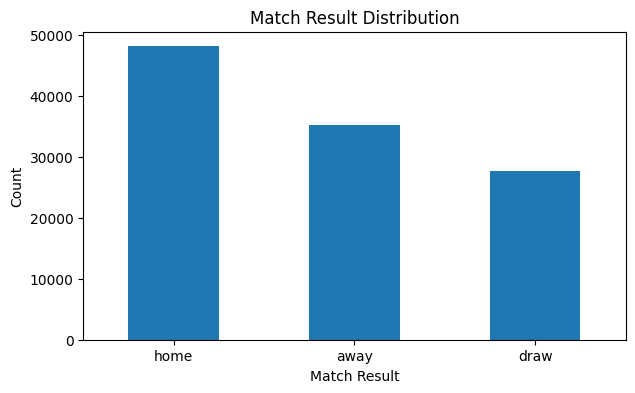

In [11]:
soccer_df["match_result"].value_counts().plot(kind="bar", figsize=(7, 4))

plt.title("Match Result Distribution")
plt.xlabel("Match Result")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## missing data

1. drop all the rows containing missing values
2. drop the feature with a high percent of missing values (70 80 %)
3. imputation (filling them) (best ig)
4. forward or backward fill (what is next? fill with it or what is beforehand? fill with it)


* the distribution will change if you fill them with mean
--------------------------------------------------------------------------------------------------------------------------------
* Numeric

1. fill with mean of kkn
2. if the models needs to treat imputated missing values differently, use an out of range number to send the signal
3. if the number used in the previous step was dummy, use mean + 3 the standard deviation

* categorical

1. fill with mode
2. if the models needs to treat imputated missing values differently, use `unknown` or `missing` to send the signal and create a new category

In [12]:
nan_percent = soccer_df.isna().mean().mul(100).sort_values(ascending=False)
nan_percent

away_club_recent_manager_id_10    24.454200
home_club_recent_manager_id_10    24.025131
away_club_recent_manager_id_9     23.571725
home_club_recent_manager_id_9     23.195839
away_club_recent_manager_id_8     22.732517
                                    ...    
home_club                          0.000901
competition_code                   0.000000
match_id                           0.000000
match_result                       0.000000
fixture_date                       0.000000
Length: 190, dtype: float64

In [13]:
nan_table = pd.DataFrame({
    "nan_count": soccer_df.isna().sum(),
    "nan_percent": soccer_df.isna().mean().mul(100),
    "dtype": soccer_df.dtypes,
    "unique_count": soccer_df.nunique(dropna=True)
}).sort_values("nan_percent", ascending=False)

nan_table[nan_table["nan_count"] > 0]

,nan_count,nan_percent,dtype,unique_count
away_club_recent_manager_id_10,27129,24.454200,float64,7936
home_club_recent_manager_id_10,26653,24.025131,float64,7891
away_club_recent_manager_id_9,26150,23.571725,float64,8044
home_club_recent_manager_id_9,25733,23.195839,float64,8002
away_club_recent_manager_id_8,25219,22.732517,float64,8144
...,...,...,...,...
home_club_recent_competition_code_1,1159,1.044728,float64,872
competition,1,0.000901,object,727
cup_game,1,0.000901,object,2
away_club,1,0.000901,object,9892


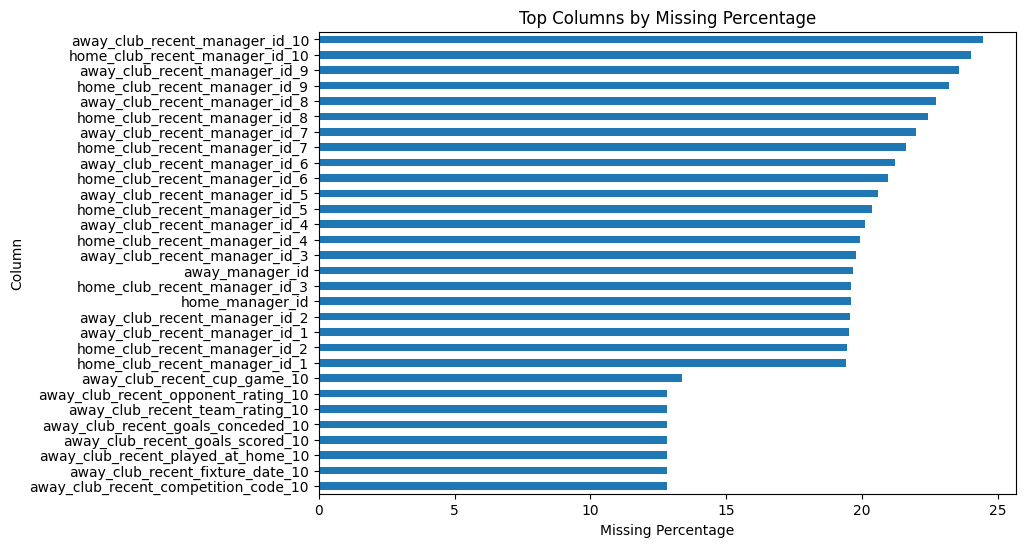

In [14]:
nan_percent[nan_percent > 0].head(30).sort_values().plot(kind="barh", figsize=(9, 6))

plt.title("Top Columns by Missing Percentage")
plt.xlabel("Missing Percentage")
plt.ylabel("Column")
plt.show()

## handling duplicates

1. remove them (if you don't want the model to treat the duplicates as important data)

before filling or handling the missing values so we don't make mistake

In [15]:
soccer_df.duplicated().sum().sum()

np.int64(0)

In [16]:
soccer_df["match_id"].duplicated().sum()

np.int64(0)

In [18]:
cols_except_match_id = soccer_df.columns.drop("match_id")
soccer_df.duplicated(subset=cols_except_match_id, keep=False).sum()

np.int64(34)

In [19]:
soccer_df = soccer_df.drop_duplicates(subset=cols_except_match_id, keep='first')

In [20]:
soccer_df.shape # 17 fewer

(110921, 190)

## numeric columns overview

In [21]:
column_overview = pd.DataFrame({
    "dtype": soccer_df.dtypes,
    "nan_count": soccer_df.isna().sum(),
    "nan_percent": soccer_df.isna().mean().mul(100),
    "unique_count": soccer_df.nunique(dropna=True)
}).sort_values("nan_percent", ascending=False)

column_overview

,dtype,nan_count,nan_percent,unique_count
away_club_recent_manager_id_10,float64,27128,24.457046,7936
home_club_recent_manager_id_10,float64,26651,24.027010,7891
away_club_recent_manager_id_9,float64,26150,23.575337,8044
home_club_recent_manager_id_9,float64,25732,23.198493,8002
away_club_recent_manager_id_8,float64,25218,22.735100,8144
...,...,...,...,...
home_club,object,1,0.000902,9813
competition_code,int64,0,0.000000,862
match_id,int64,0,0.000000,110921
match_result,object,0,0.000000,3


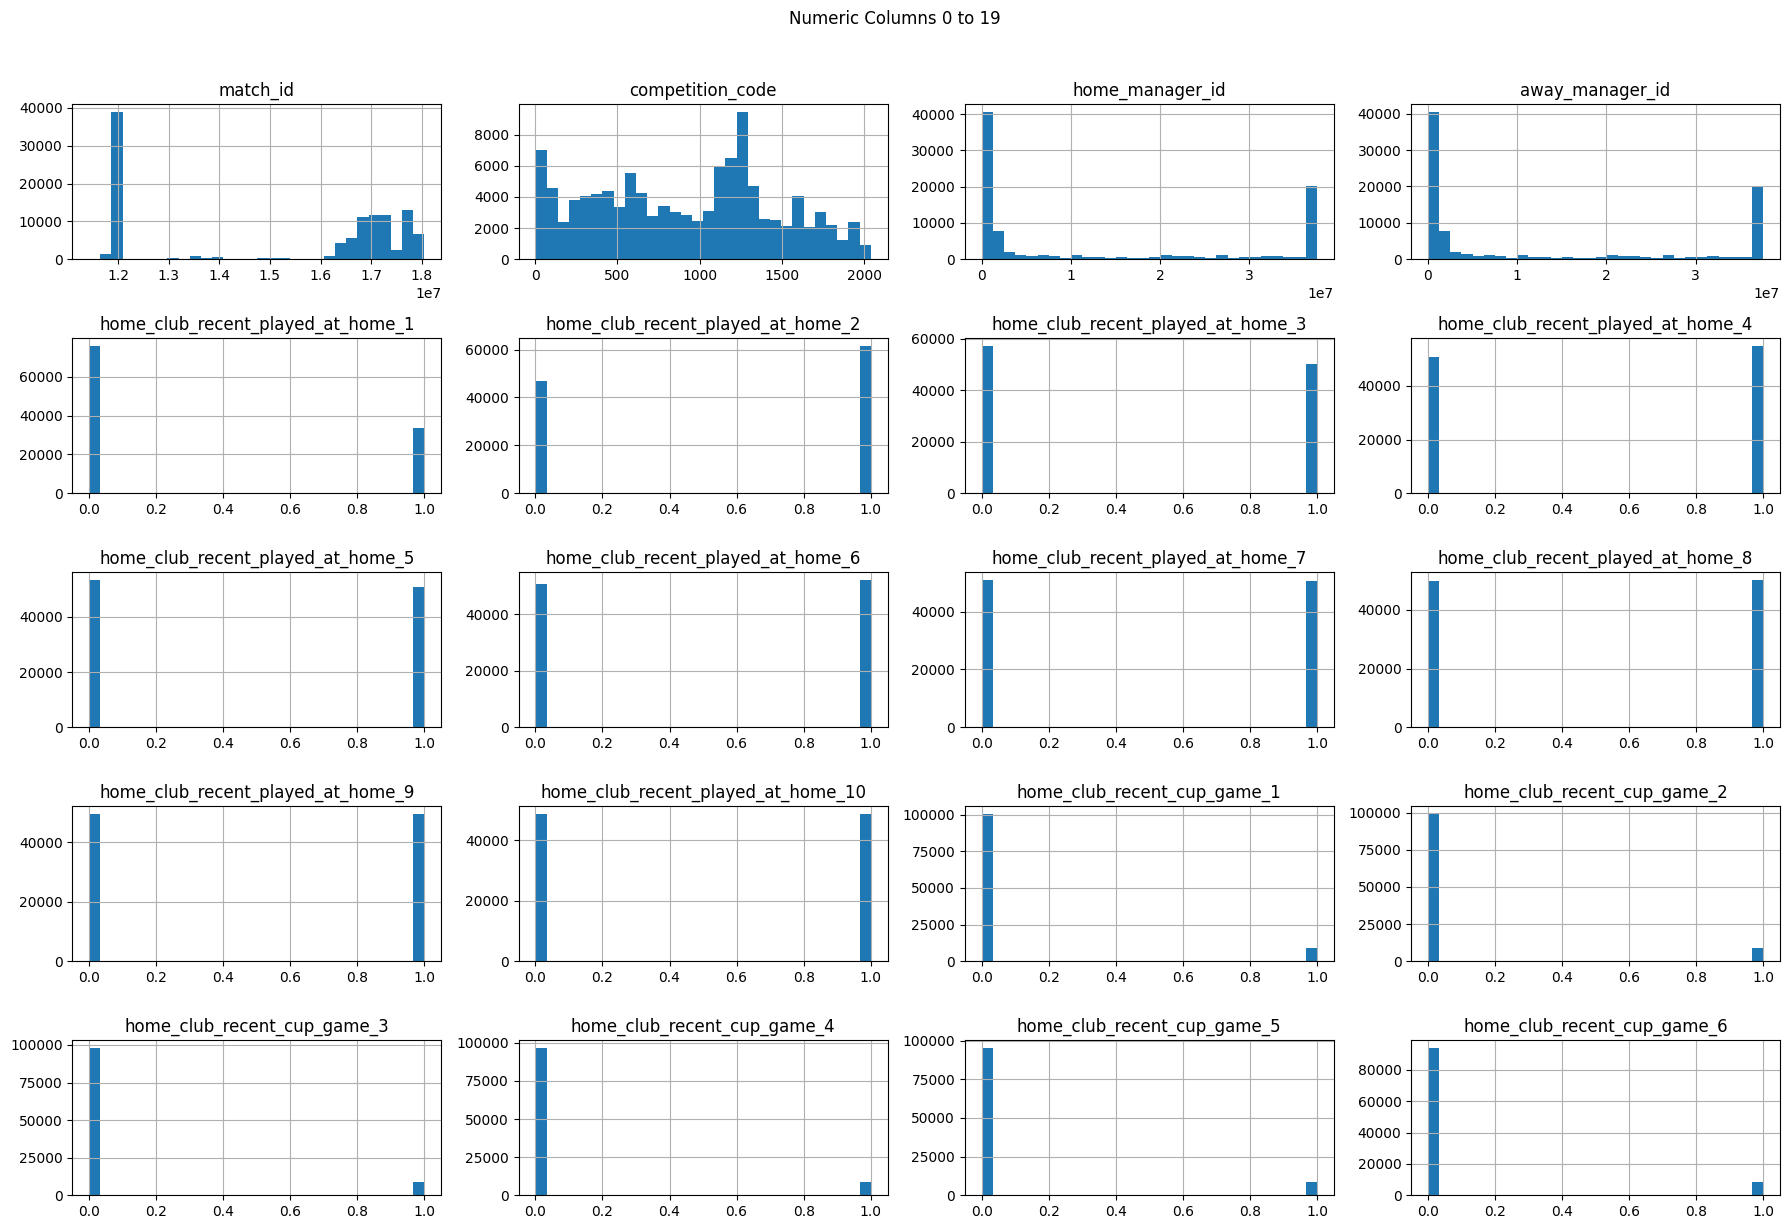

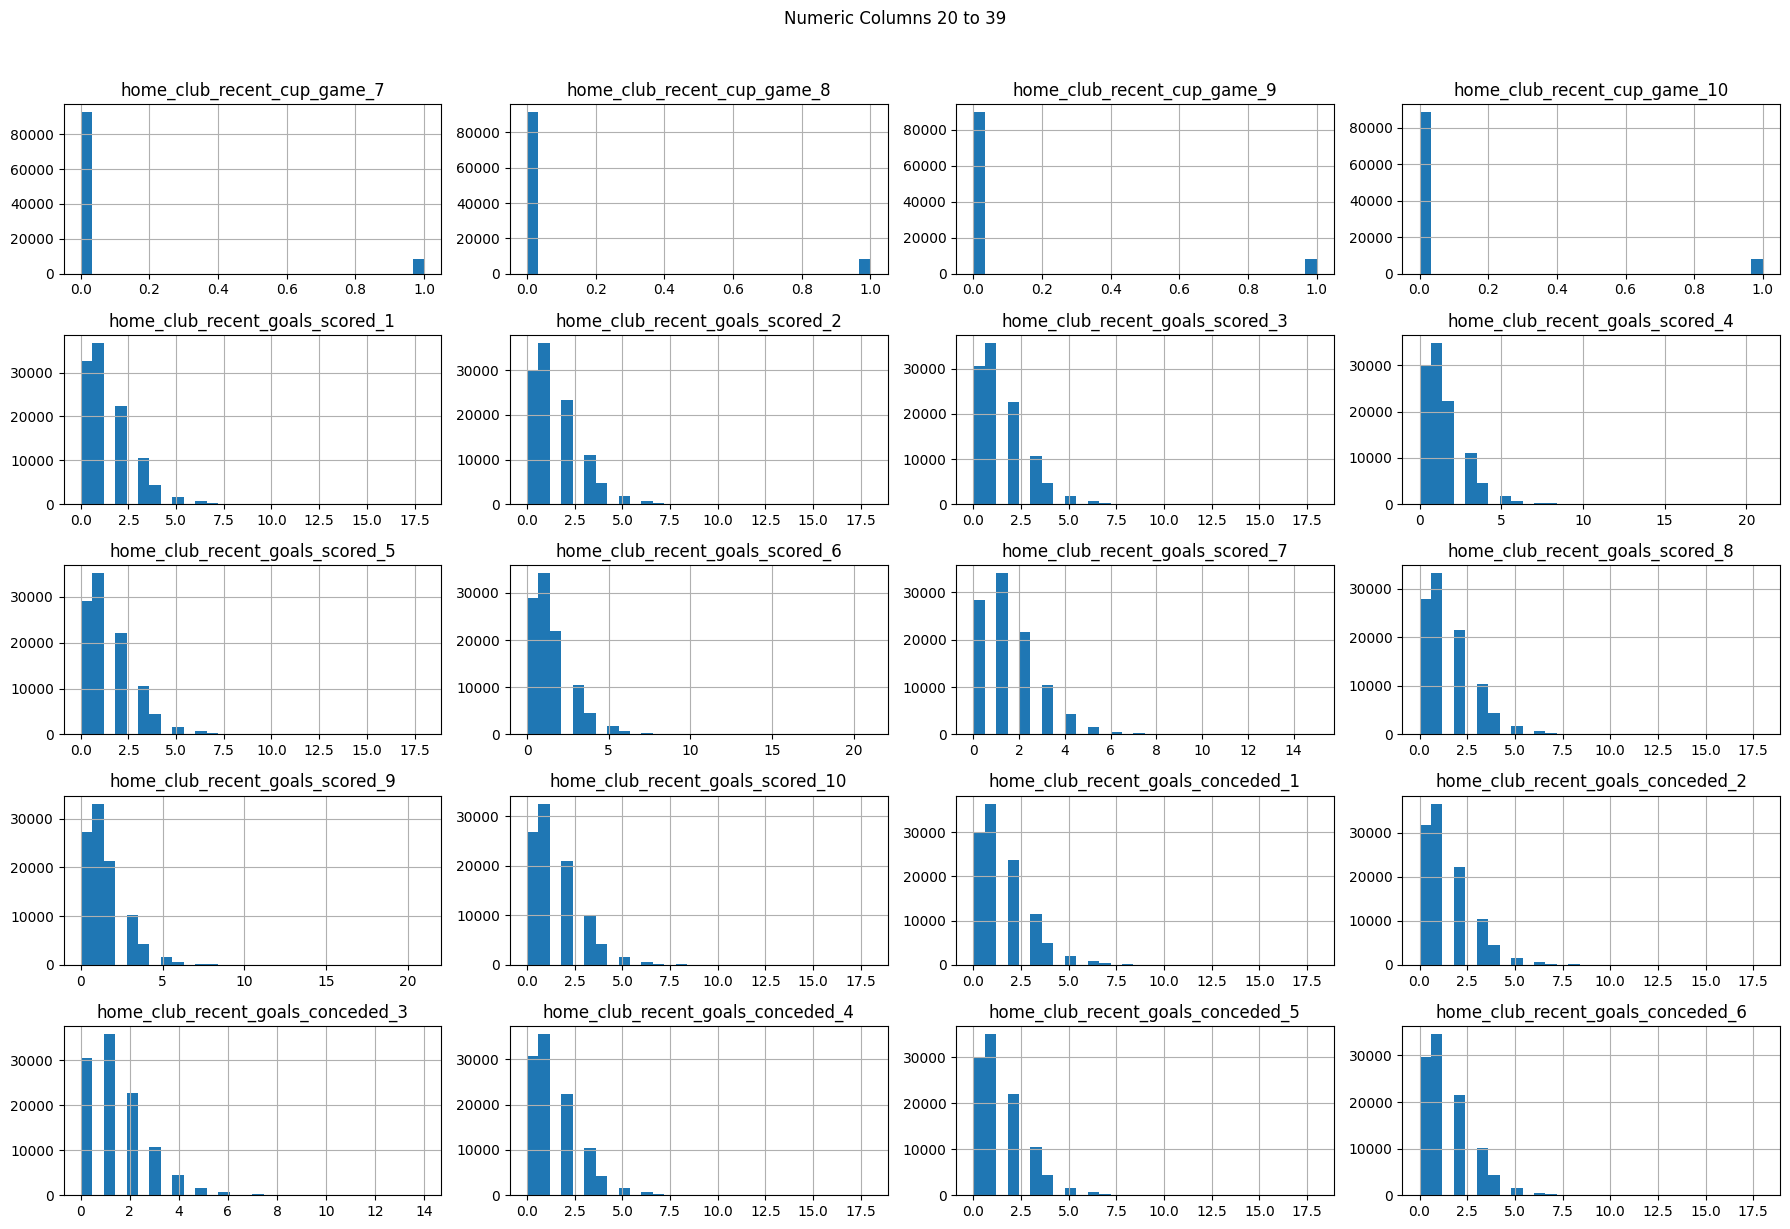

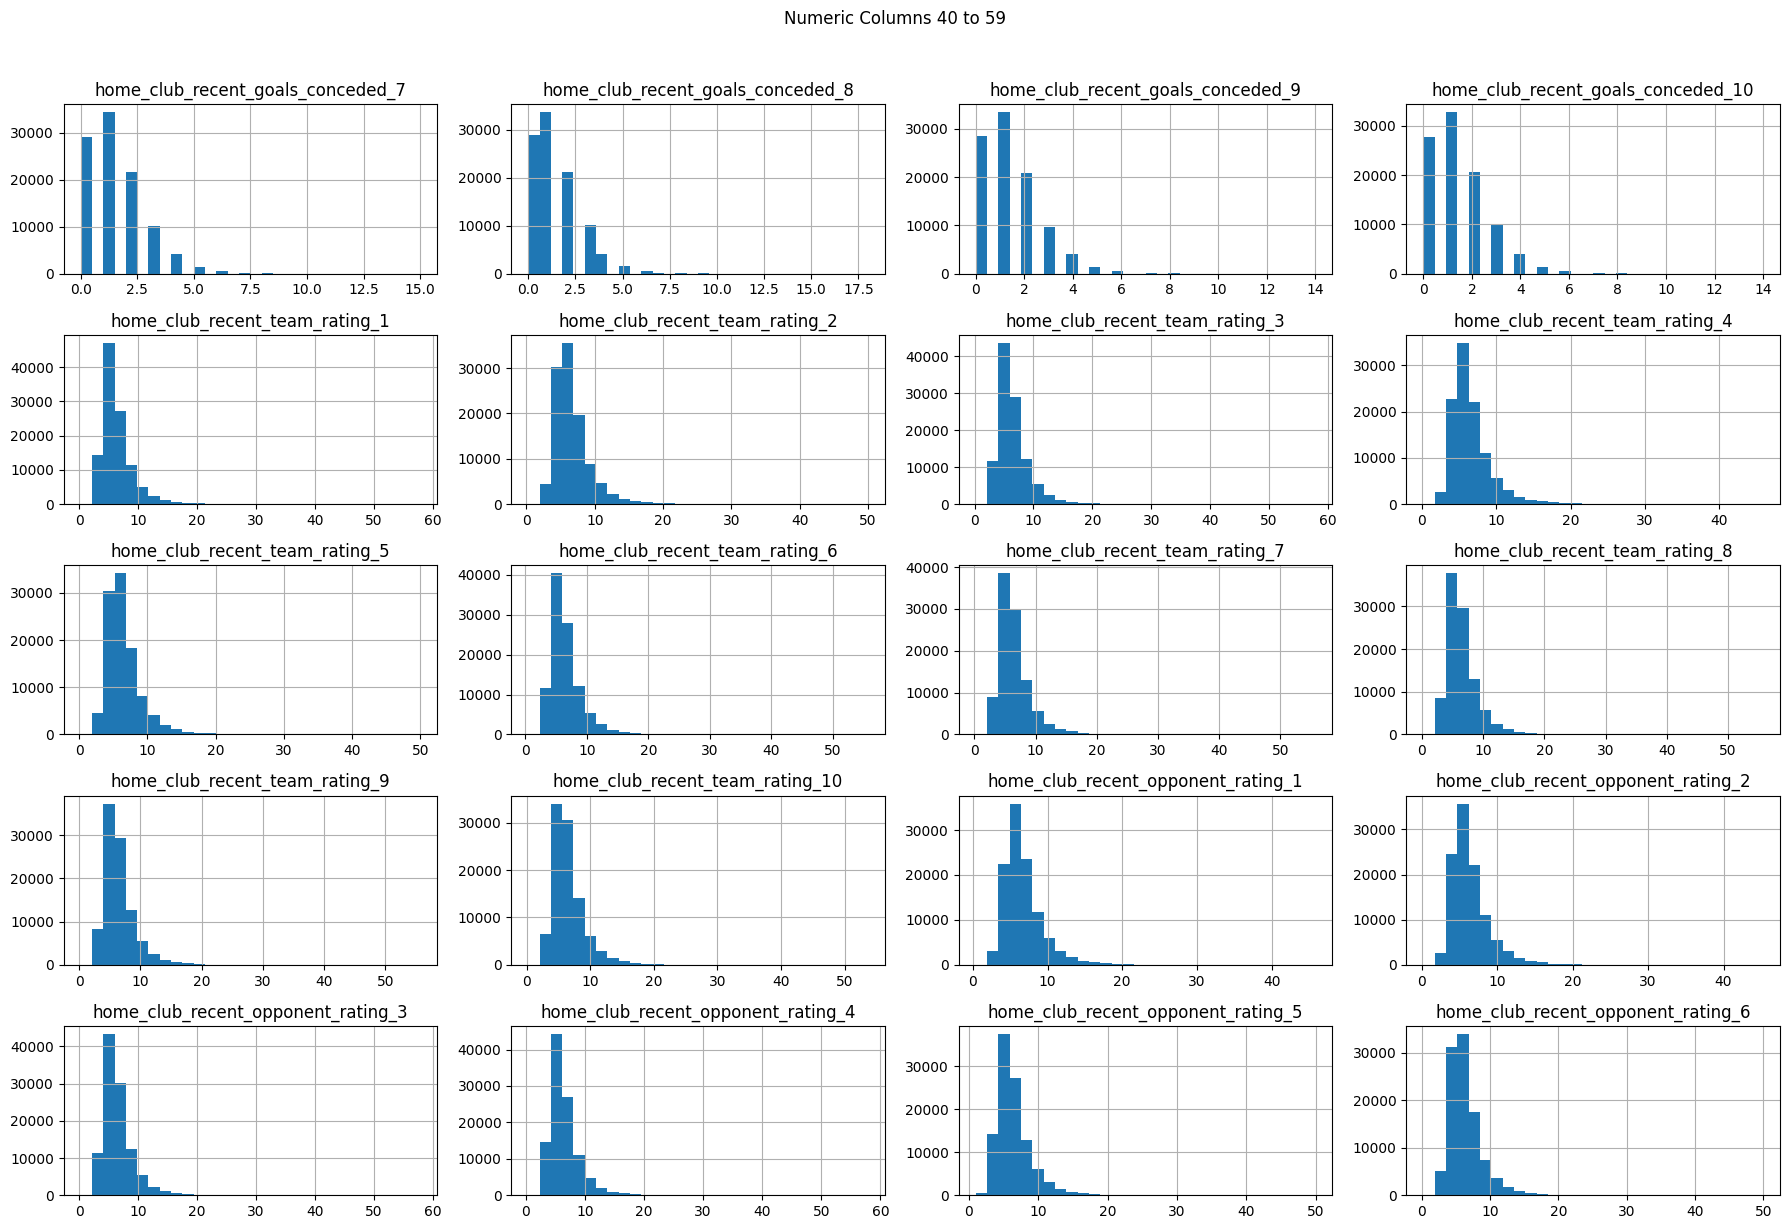

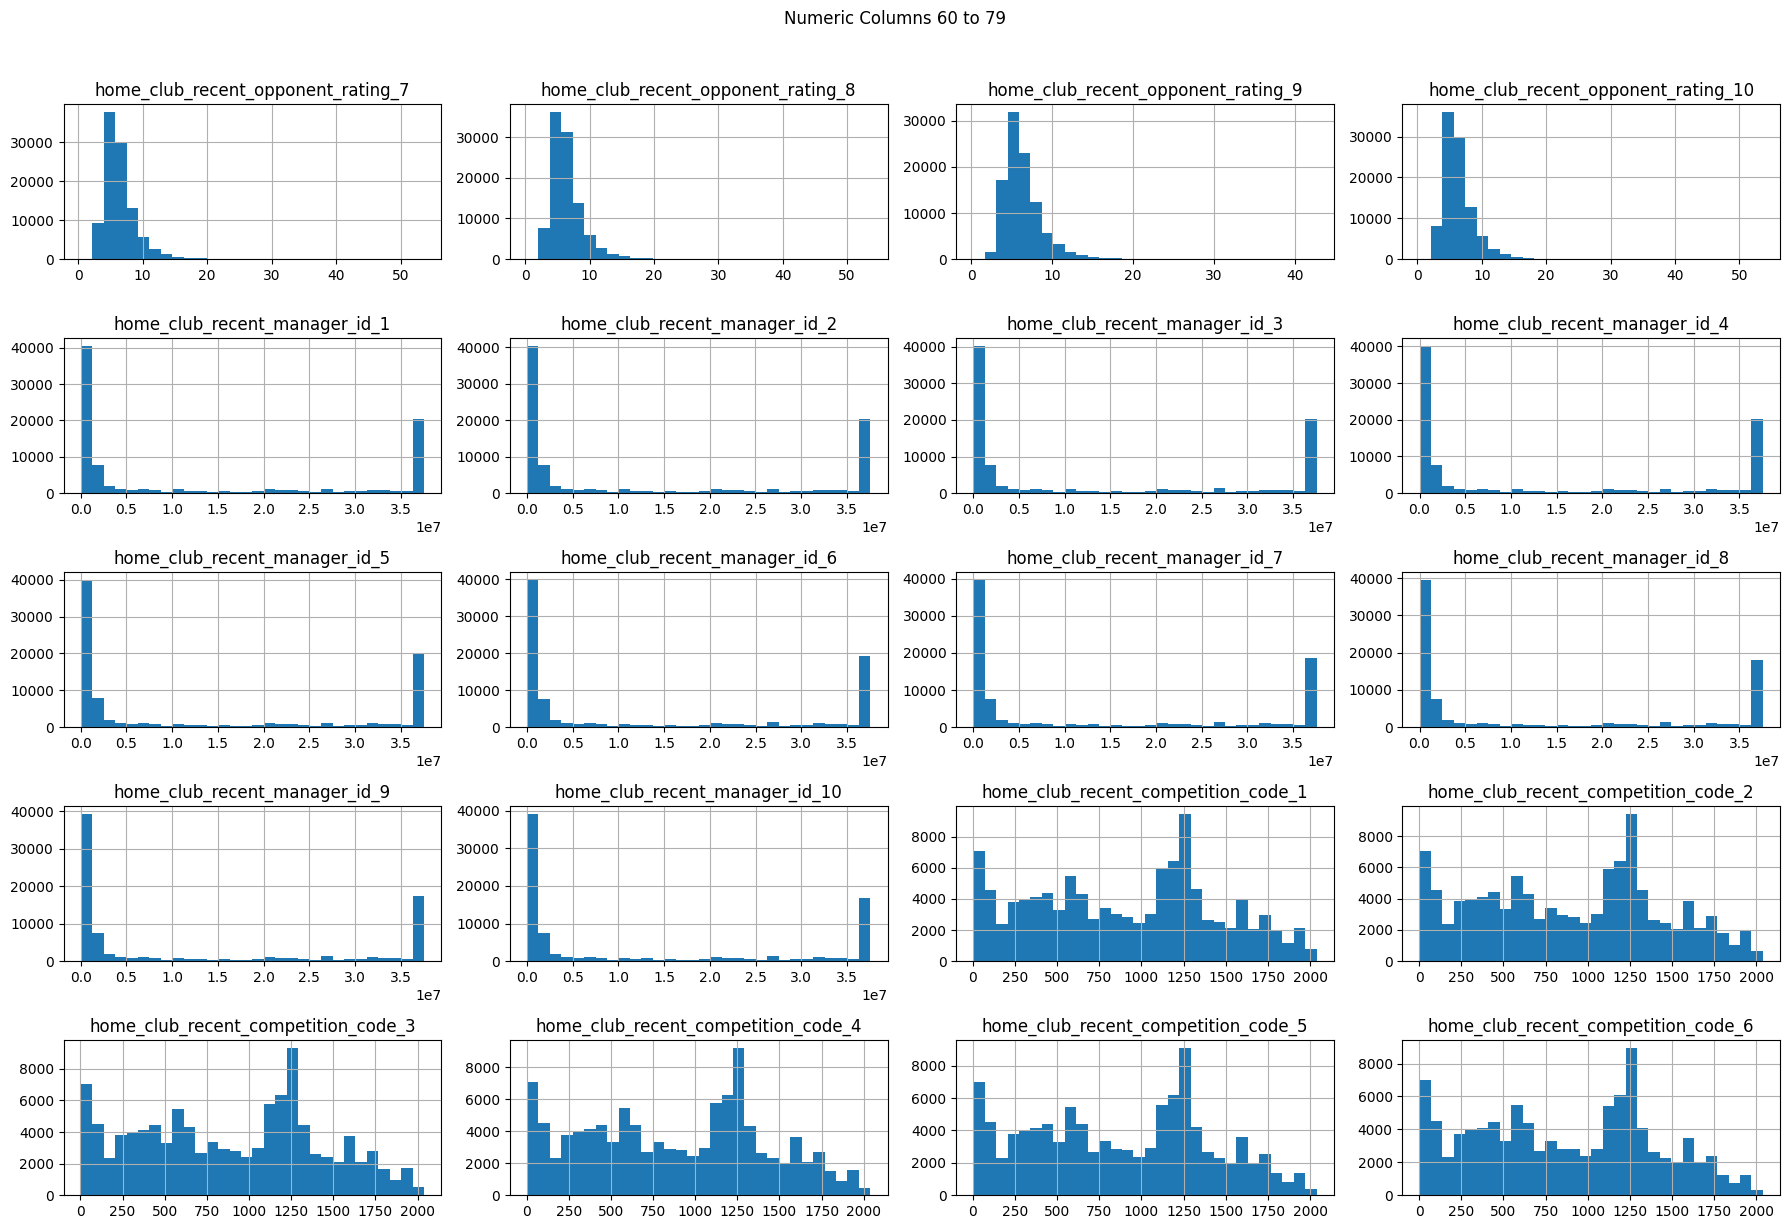

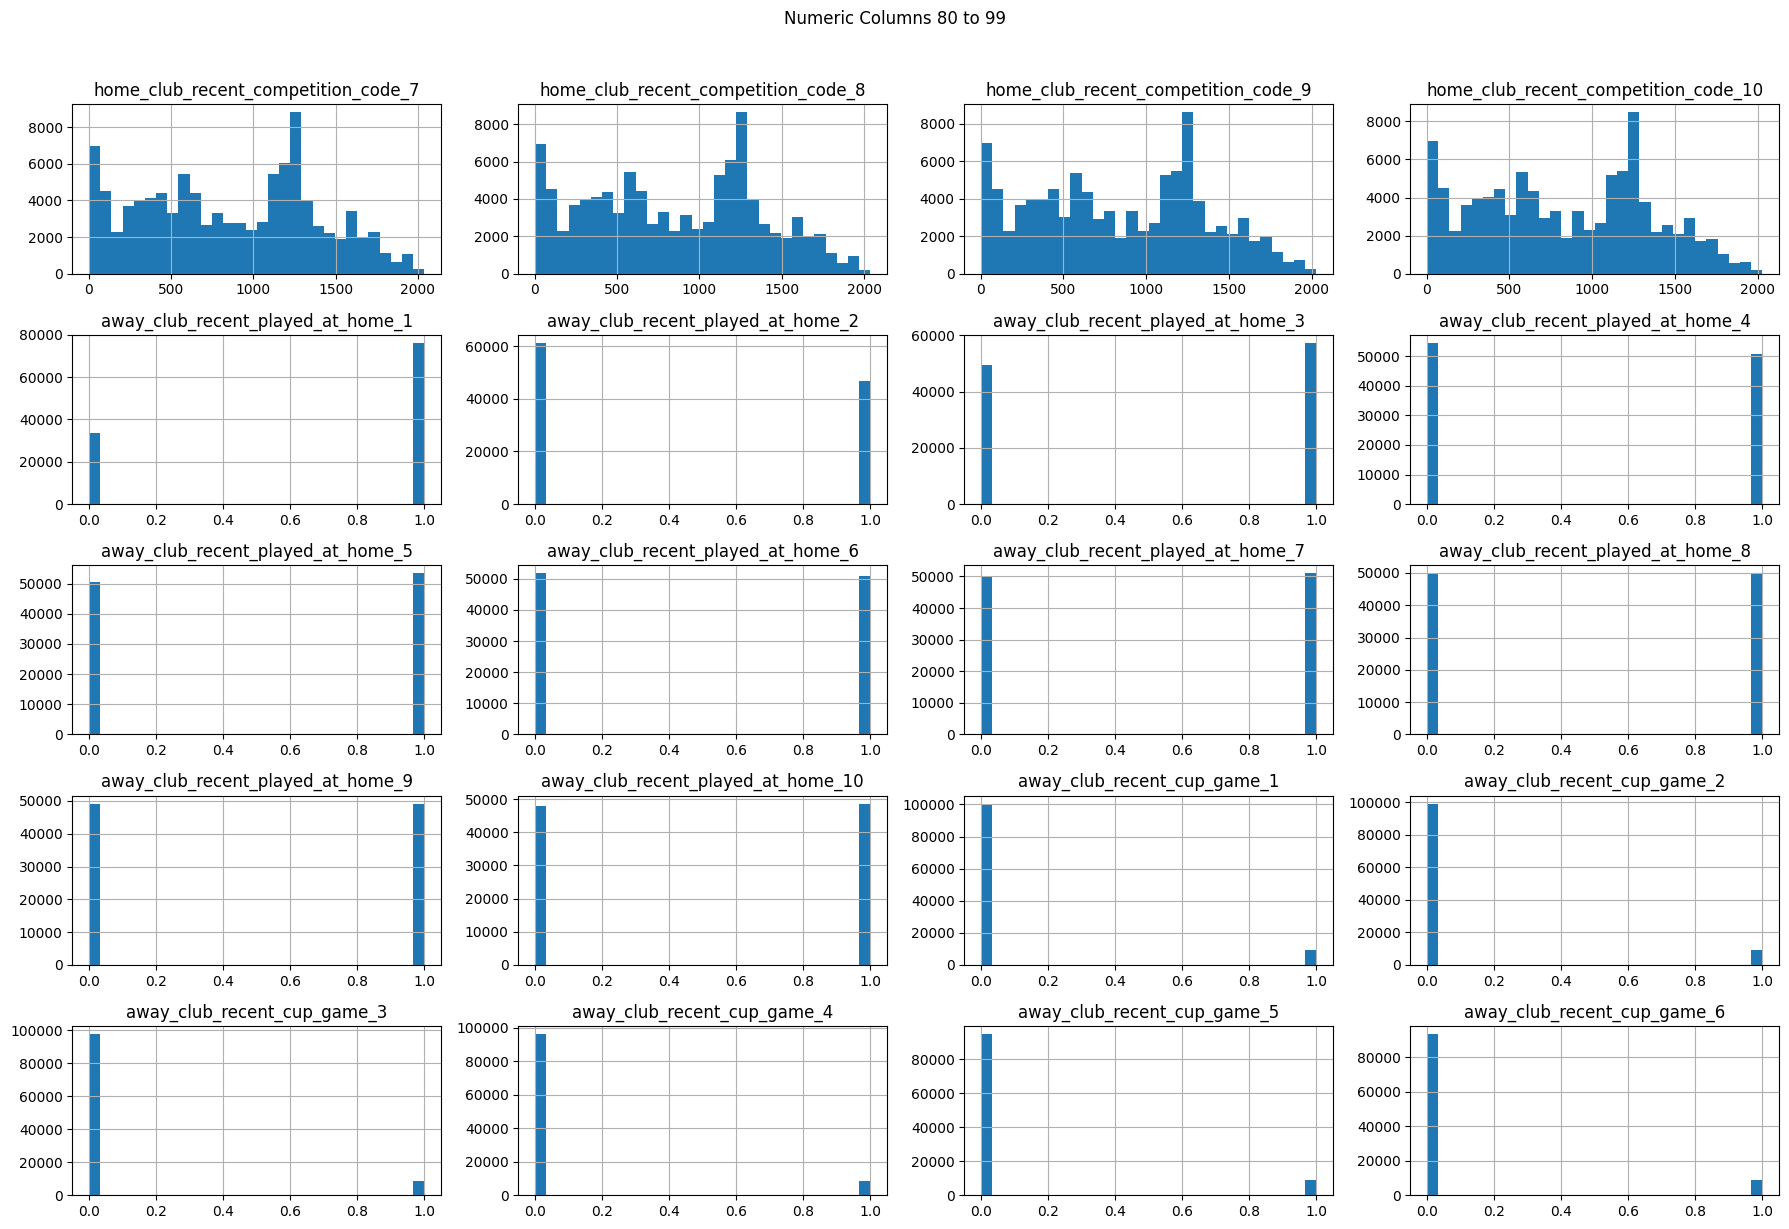

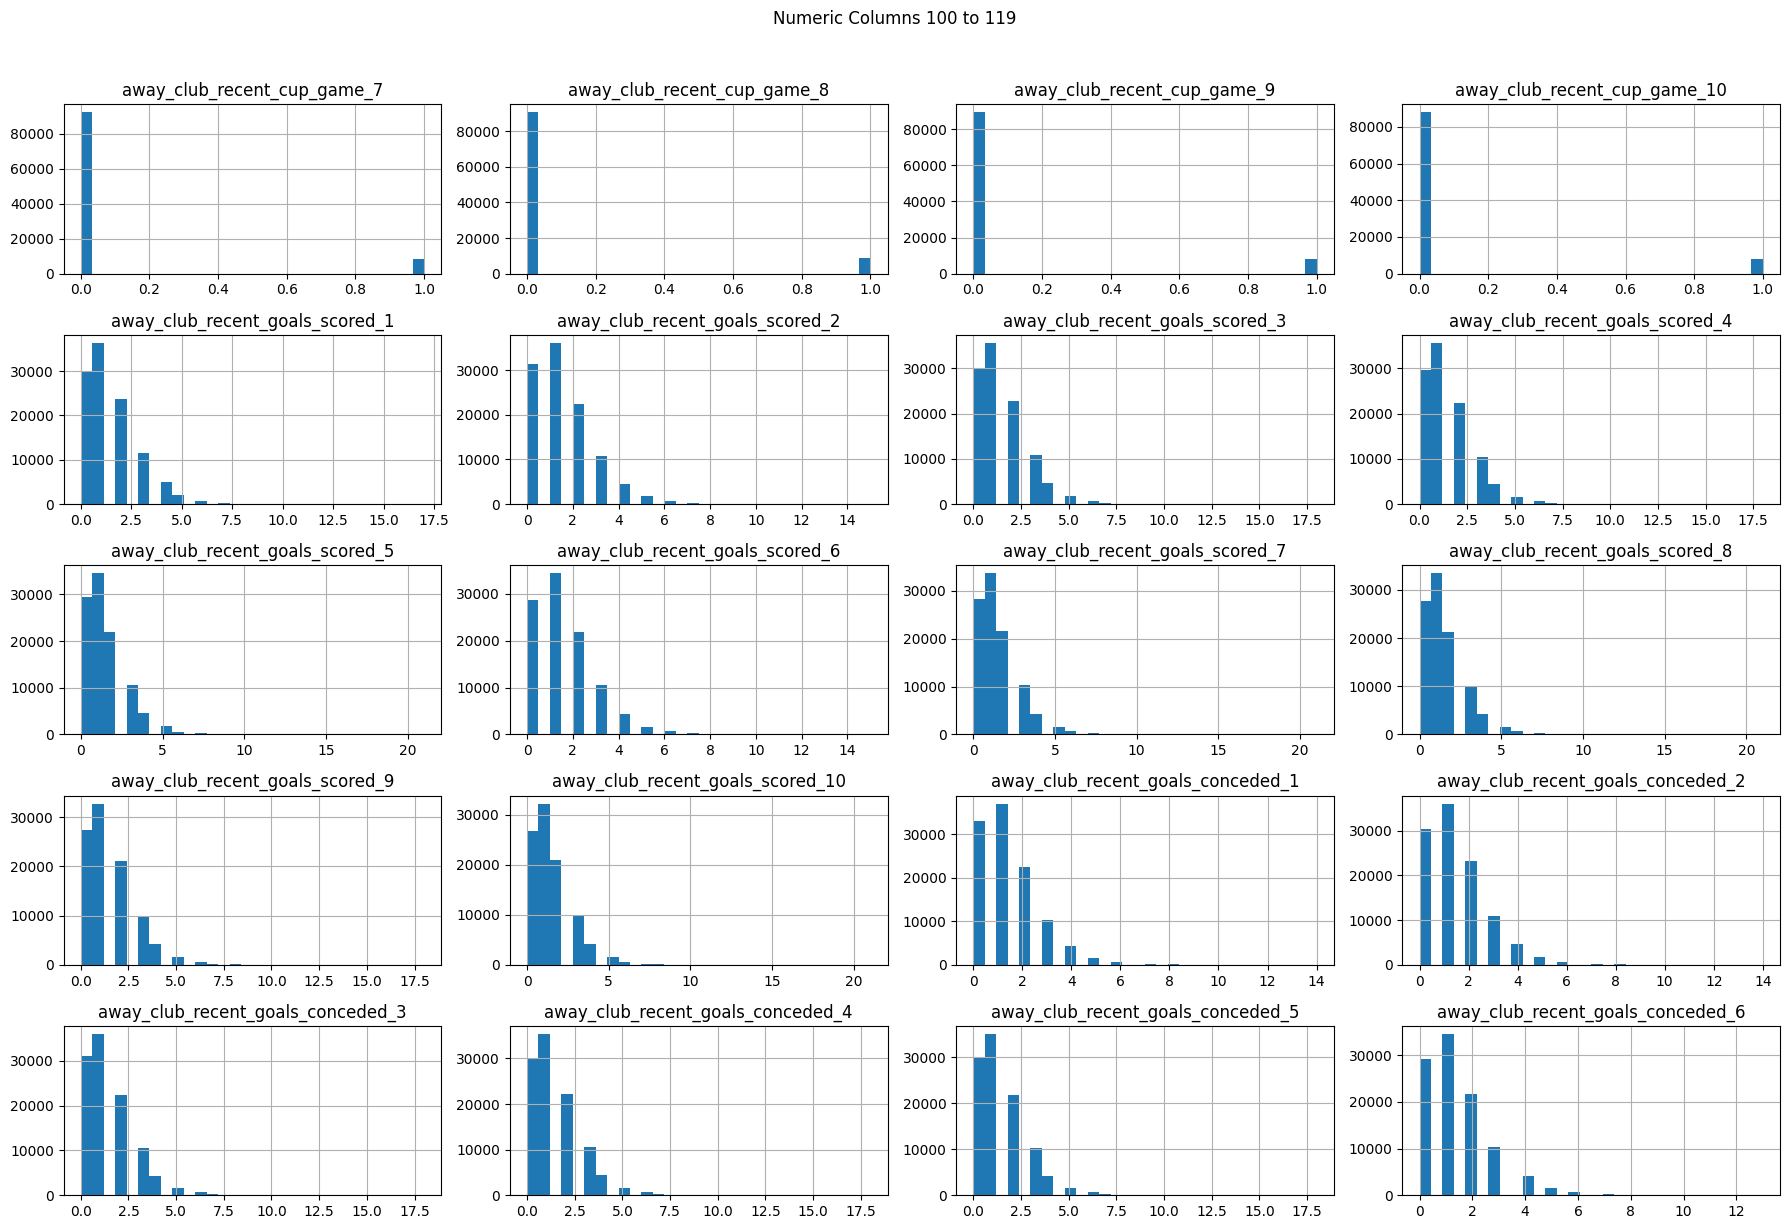

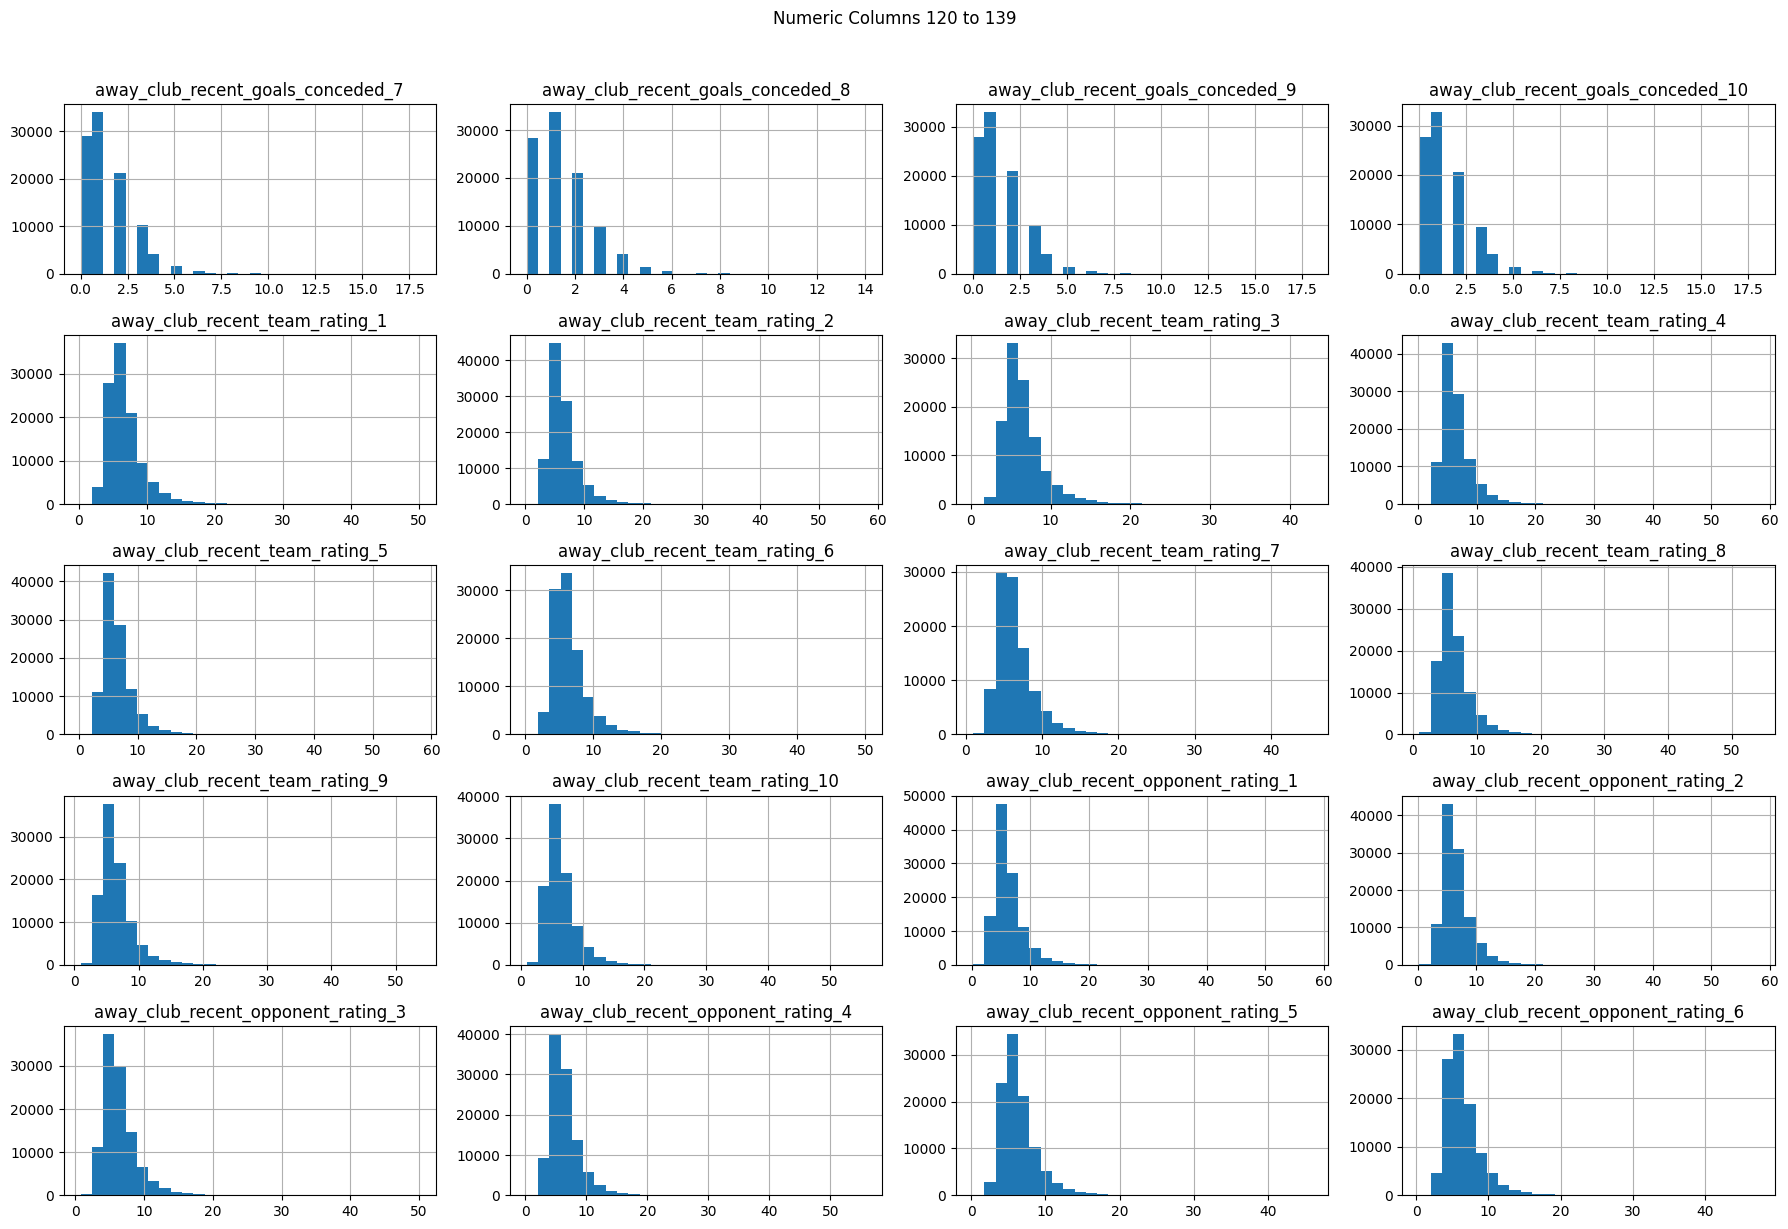

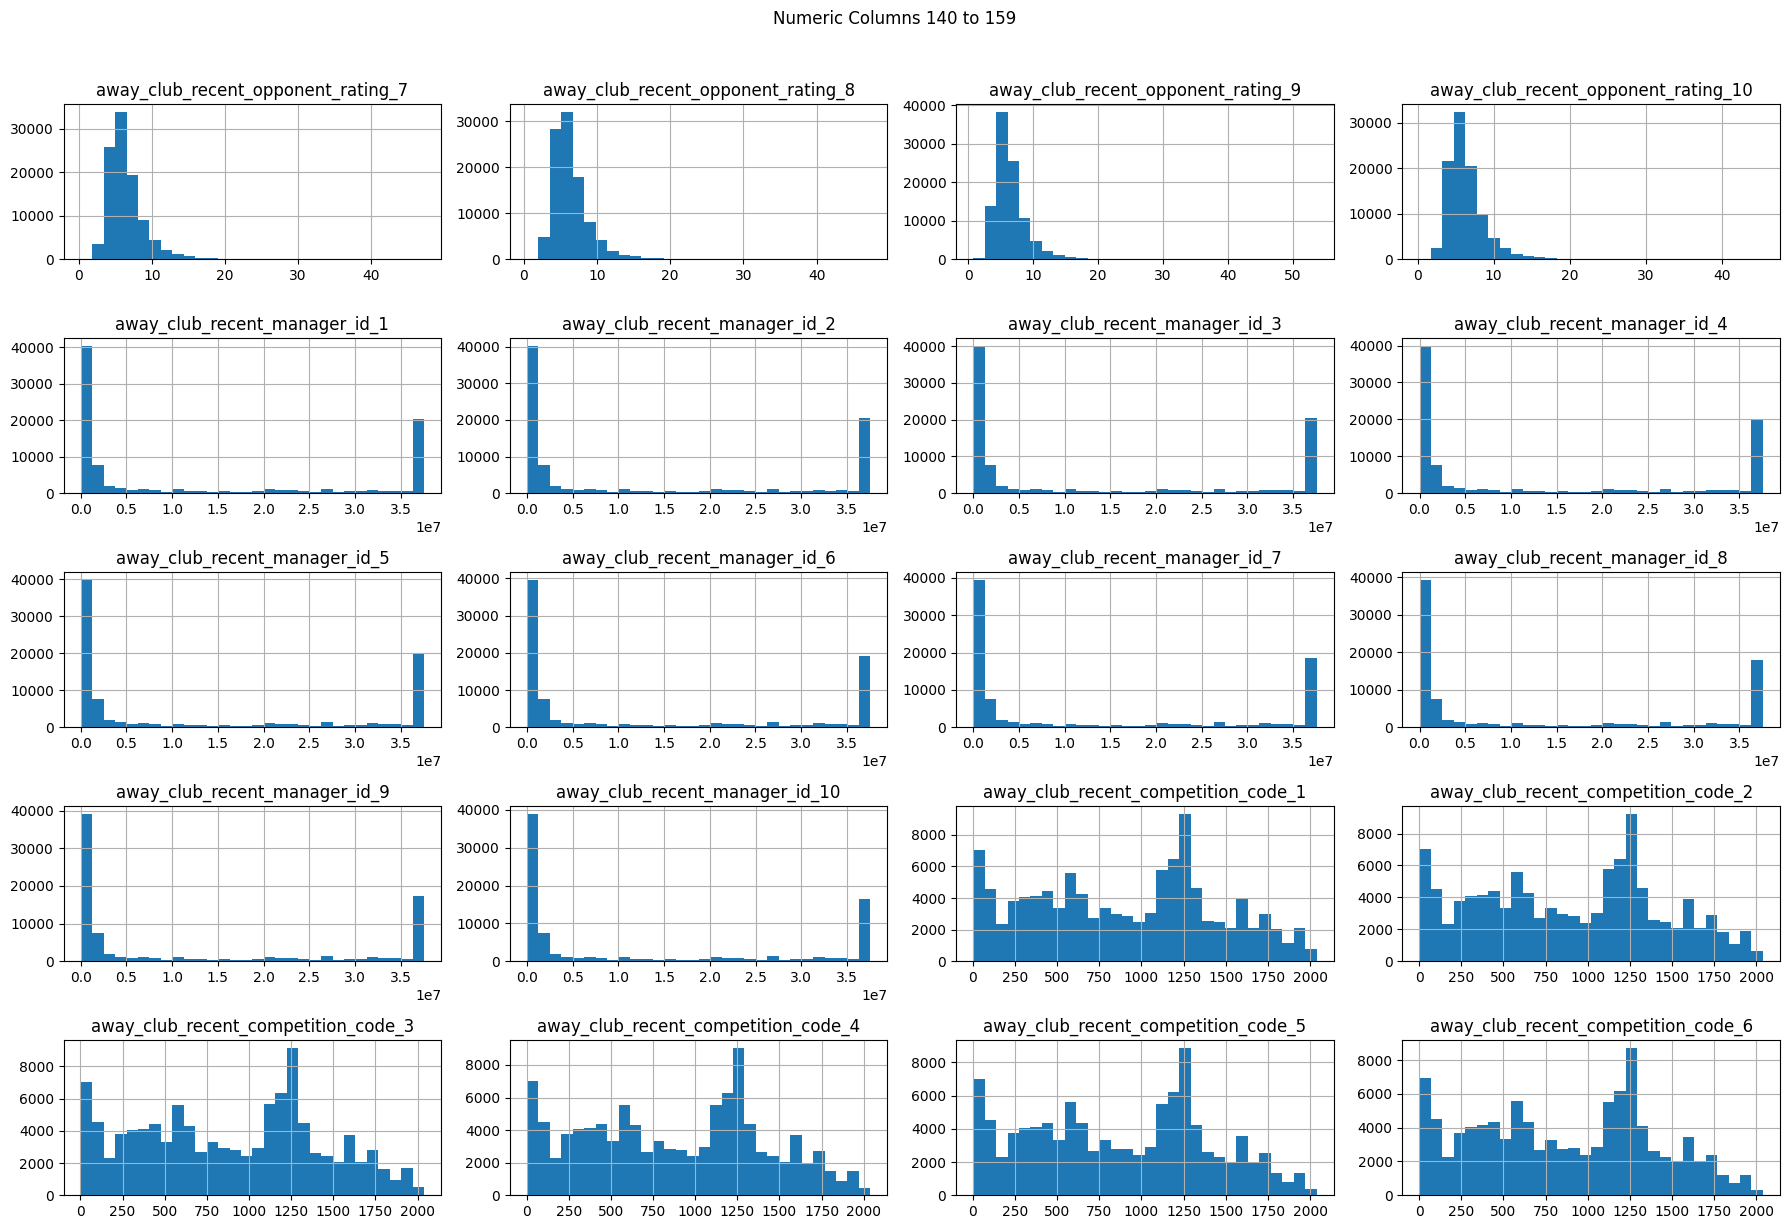

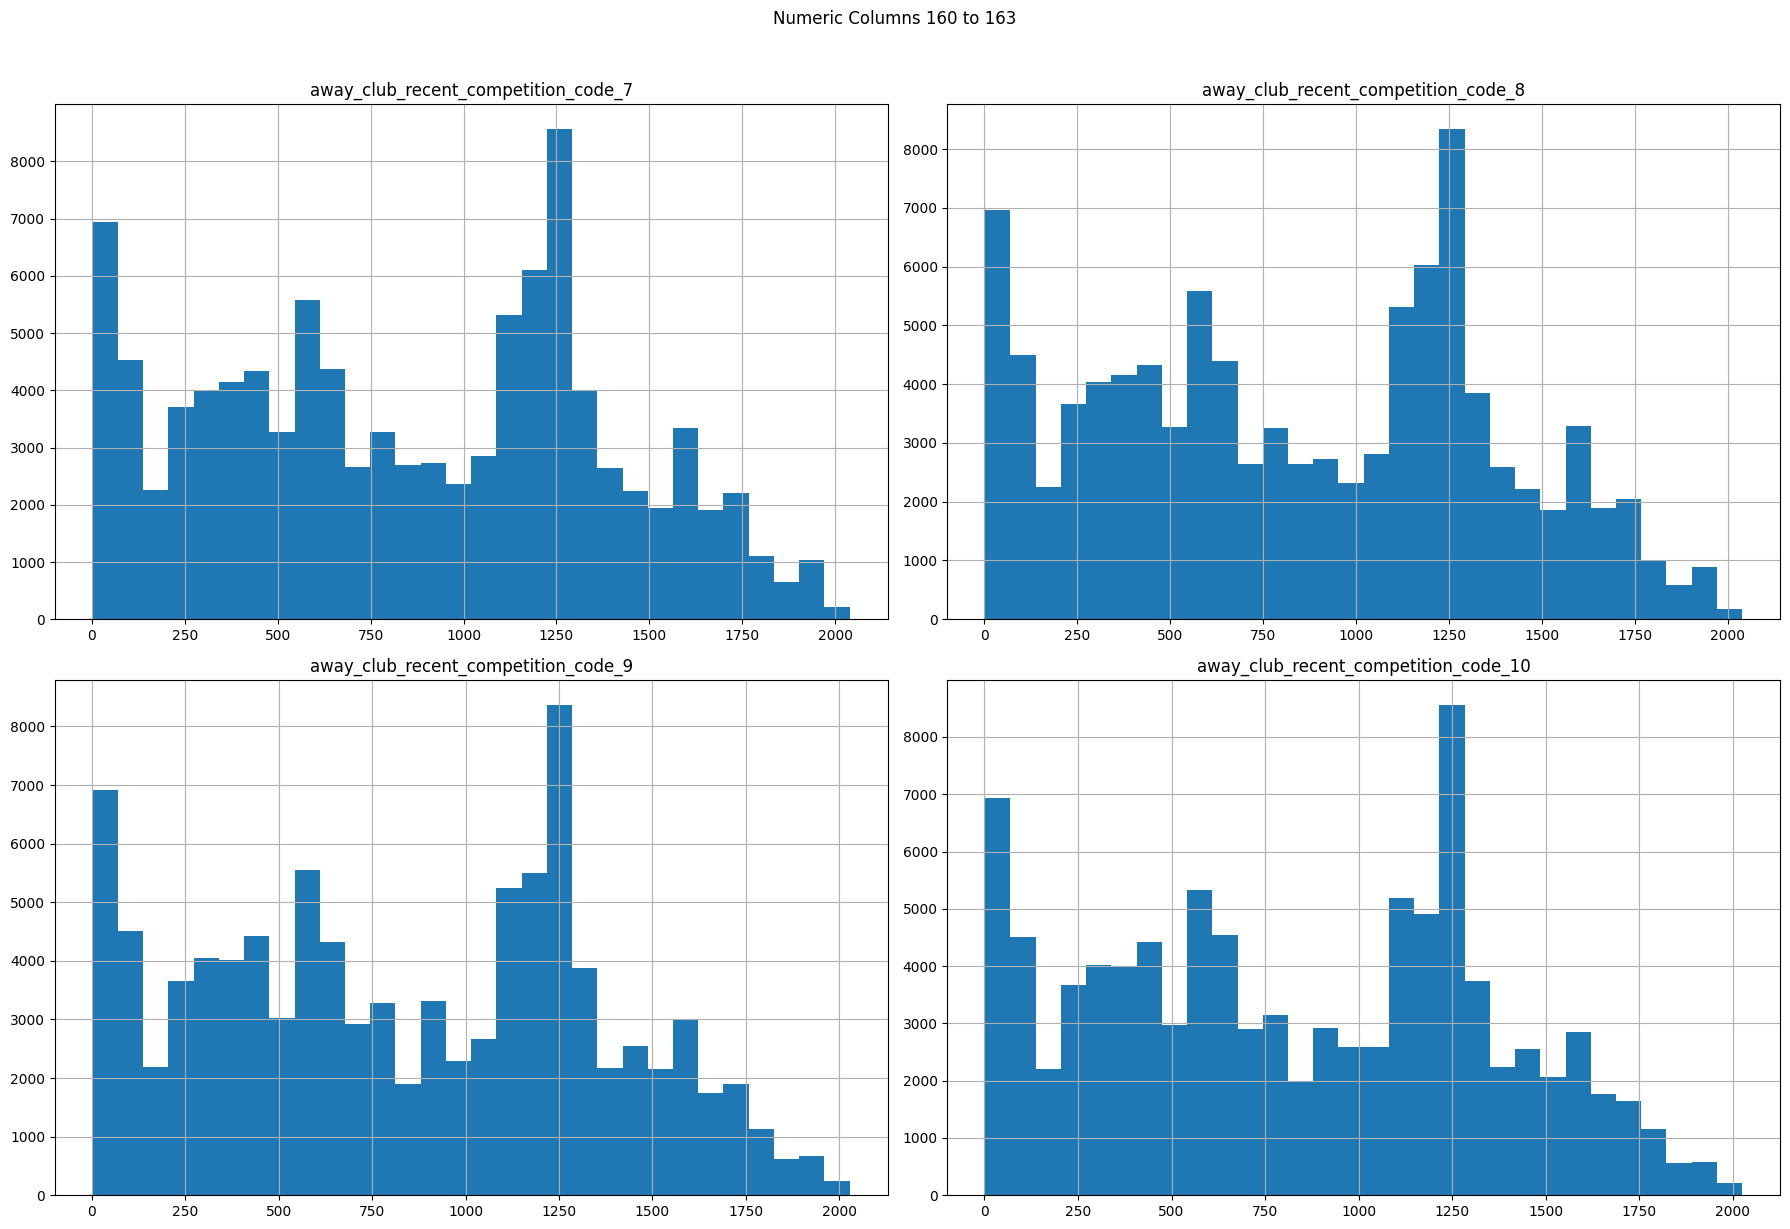

In [22]:
numeric_cols = soccer_df.select_dtypes(include="number").columns

for start in range(0, len(numeric_cols), 20):
    cols = numeric_cols[start:start+20]
    
    soccer_df[cols].hist(figsize=(18, 12), bins=30)
    plt.suptitle(f"Numeric Columns {start} to {start + len(cols) - 1}", y=1.02)
    plt.tight_layout()
    plt.show()

## Categorical columns overview

In [23]:
categorical_cols = soccer_df.select_dtypes(include=["object", "string", "category", "bool"]).columns

cat_overview = pd.DataFrame({
    "dtype": soccer_df[categorical_cols].dtypes,
    "nan_count": soccer_df[categorical_cols].isna().sum(),
    "nan_percent": soccer_df[categorical_cols].isna().mean().mul(100),
    "unique_count": soccer_df[categorical_cols].nunique(dropna=True)
}).sort_values("unique_count", ascending=False)

cat_overview

,dtype,nan_count,nan_percent,unique_count
fixture_date,object,0,0.000000,20269
away_club_recent_fixture_date_5,object,7000,6.310798,19871
home_club_recent_fixture_date_5,object,6477,5.839291,19850
home_club_recent_fixture_date_6,object,7896,7.118580,19832
home_club_recent_fixture_date_7,object,9295,8.379838,19799
away_club_recent_fixture_date_7,object,9867,8.895520,19788
home_club_recent_fixture_date_8,object,10719,9.663634,19764
home_club_recent_fixture_date_4,object,5101,4.598768,19763
away_club_recent_fixture_date_6,object,8426,7.596397,19748
away_club_recent_fixture_date_4,object,5516,4.972909,19709


## handling missing values

In [24]:
nan_table[nan_table["nan_count"] > 0]

,nan_count,nan_percent,dtype,unique_count
away_club_recent_manager_id_10,27129,24.454200,float64,7936
home_club_recent_manager_id_10,26653,24.025131,float64,7891
away_club_recent_manager_id_9,26150,23.571725,float64,8044
home_club_recent_manager_id_9,25733,23.195839,float64,8002
away_club_recent_manager_id_8,25219,22.732517,float64,8144
...,...,...,...,...
home_club_recent_competition_code_1,1159,1.044728,float64,872
competition,1,0.000901,object,727
cup_game,1,0.000901,object,2
away_club,1,0.000901,object,9892


In [25]:
x = soccer_df.drop(columns=["match_result", "match_id"], errors="ignore")
y = soccer_df["match_result"]

stratify=y makes sure the target classes have almost the same percentage in both train and test.stratify=y makes sure the target classes have almost the same percentage in both train and test.

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

we've coverd all the cols

## creating features with recent date data using feature engineering

In [28]:
from sklearn.preprocessing import FunctionTransformer
import pandas as pd

def add_soccer_features(X):
    X = X.copy()

    # =========================
    # 1. Date-based features
    # =========================
    if "fixture_date" in X.columns:
        fixture_date = pd.to_datetime(X["fixture_date"], errors="coerce")

        X["fixture_year"] = fixture_date.dt.year
        X["fixture_month"] = fixture_date.dt.month
        X["fixture_dayofweek"] = fixture_date.dt.dayofweek

        recent_date_cols = X.columns[X.columns.str.contains("recent_fixture_date")]

        for col in recent_date_cols:
            recent_date = pd.to_datetime(X[col], errors="coerce")
            new_col = col.replace("fixture_date", "days_before_match")
            X[new_col] = (fixture_date - recent_date).dt.days

        X = X.drop(columns=list(recent_date_cols) + ["fixture_date"], errors="ignore")

    # =========================
    # 2. Helper functions
    # =========================
    def get_cols(side, feature_name, last_n=5):
        return [f"{side}_recent_{feature_name}_{i}" for i in range(1, last_n + 1) if f"{side}_recent_{feature_name}_{i}" in X.columns]

    def row_mean(cols):
        if len(cols) == 0:
            return pd.Series(index=X.index, dtype="float64")
        return X[cols].apply(pd.to_numeric, errors="coerce").mean(axis=1)

    def row_count_available(cols):
        if len(cols) == 0:
            return pd.Series(index=X.index, dtype="float64")
        return X[cols].apply(pd.to_numeric, errors="coerce").notna().sum(axis=1)

    # =========================
    # 3. Recent goal features
    # =========================
    X["home_avg_goals_scored_last5"] = row_mean(get_cols("home_club", "goals_scored", last_n=5))
    X["away_avg_goals_scored_last5"] = row_mean(get_cols("away_club", "goals_scored", last_n=5))

    X["home_avg_goals_conceded_last5"] = row_mean(get_cols("home_club", "goals_conceded", last_n=5))
    X["away_avg_goals_conceded_last5"] = row_mean(get_cols("away_club", "goals_conceded", last_n=5))

    X["home_goal_diff_last5"] = (X["home_avg_goals_scored_last5"] - X["home_avg_goals_conceded_last5"])
    X["away_goal_diff_last5"] = (X["away_avg_goals_scored_last5"] - X["away_avg_goals_conceded_last5"])

    X["goal_diff_form_diff"] = (X["home_goal_diff_last5"] - X["away_goal_diff_last5"])

    # =========================
    # 4. Recent rating features
    # =========================
    X["home_avg_team_rating_last5"] = row_mean(get_cols("home_club", "team_rating", last_n=5))
    X["away_avg_team_rating_last5"] = row_mean(get_cols("away_club", "team_rating", last_n=5))

    X["home_avg_opponent_rating_last5"] = row_mean(get_cols("home_club", "opponent_rating", last_n=5))
    X["away_avg_opponent_rating_last5"] = row_mean(get_cols("away_club", "opponent_rating", last_n=5))

    X["home_form_strength"] = (X["home_avg_team_rating_last5"] - X["home_avg_opponent_rating_last5"])
    X["away_form_strength"] = (X["away_avg_team_rating_last5"] - X["away_avg_opponent_rating_last5"])

    X["rating_diff"] = (X["home_avg_team_rating_last5"] - X["away_avg_team_rating_last5"])
    X["form_strength_diff"] = (X["home_form_strength"] - X["away_form_strength"])

    # =========================
    # 5. Date-derived recent features
    # =========================
    home_day_cols = [f"home_club_recent_days_before_match_{i}" for i in range(1, 11) if f"home_club_recent_days_before_match_{i}" in X.columns]

    away_day_cols = [f"away_club_recent_days_before_match_{i}" for i in range(1, 11) if f"away_club_recent_days_before_match_{i}" in X.columns]

    if "home_club_recent_days_before_match_1" in X.columns:
        X["home_rest_days"] = X["home_club_recent_days_before_match_1"]

    if "away_club_recent_days_before_match_1" in X.columns:
        X["away_rest_days"] = X["away_club_recent_days_before_match_1"]

    if "home_rest_days" in X.columns and "away_rest_days" in X.columns:
        X["rest_days_diff"] = X["home_rest_days"] - X["away_rest_days"]

    X["home_recent_fixture_available_count"] = row_count_available(home_day_cols)
    X["away_recent_fixture_available_count"] = row_count_available(away_day_cols)

    X["recent_fixture_available_count_diff"] = (X["home_recent_fixture_available_count"] - X["away_recent_fixture_available_count"])

    X["home_avg_days_before_match_last5"] = row_mean(home_day_cols[:5])
    X["away_avg_days_before_match_last5"] = row_mean(away_day_cols[:5])

    X["avg_days_before_match_diff_last5"] = (X["home_avg_days_before_match_last5"] - X["away_avg_days_before_match_last5"])

    return X


feature_engineering_transformer = FunctionTransformer(add_soccer_features, validate=False)

## outlier and IQR

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X = pd.DataFrame(X).apply(pd.to_numeric, errors="coerce")

        q1 = np.nanpercentile(X, 25, axis=0)
        q3 = np.nanpercentile(X, 75, axis=0)
        iqr = q3 - q1

        self.lower_bounds_ = q1 - self.factor * iqr
        self.upper_bounds_ = q3 + self.factor * iqr

        return self

    def transform(self, X):
        X = pd.DataFrame(X).apply(pd.to_numeric, errors="coerce")
        X_clipped = np.clip(X, self.lower_bounds_, self.upper_bounds_)

        return X_clipped

In [29]:
x_train_after_features = add_soccer_features(x_train)

x_train_after_features.head()

,home_club,away_club,competition,competition_code,cup_game,home_manager_id,away_manager_id,home_club_recent_played_at_home_1,home_club_recent_played_at_home_2,home_club_recent_played_at_home_3,...,form_strength_diff,home_rest_days,away_rest_days,rest_days_diff,home_recent_fixture_available_count,away_recent_fixture_available_count,recent_fixture_available_count_diff,home_avg_days_before_match_last5,away_avg_days_before_match_last5,avg_days_before_match_diff_last5
76694,Rennes,Metz,Ligue 1,301,False,527346.0,896572.0,0.0,1.0,0.0,...,1.788189,3.0,4.0,-1.0,10,10,0,10.2,12.2,-2.0
102389,Chindia Târgovişte,Voluntari,Liga 1,474,False,10310233.0,468304.0,0.0,1.0,0.0,...,-1.454232,18.0,16.0,2.0,10,10,0,27.6,28.8,-1.2
71162,Argeş,Dinamo Bucureşti,Liga 1,474,False,16102541.0,464626.0,0.0,0.0,1.0,...,-3.119847,6.0,5.0,1.0,10,10,0,24.2,20.6,3.6
110800,Polonia Środa,Pogon Szczecin II,3. Liga,1936,False,532886.0,NaN,0.0,1.0,0.0,...,2.561642,6.0,5.0,1.0,10,10,0,19.0,18.8,0.2
44939,Haukar,Dalvík / Reynir,2. Deild,351,False,468503.0,34573624.0,0.0,0.0,0.0,...,1.379353,3.0,3.0,0.0,10,10,0,11.0,14.0,-3.0


The raw team-name columns such as `home_club` and `away_club` were removed from the final modeling features. These variables are high-cardinality nominal categorical variables and using one-hot encoding would greatly increase the feature space, while ordinal encoding would impose an artificial order on teams. Instead, team strength was represented through engineered numerical features such as recent goals scored and conceded, recent team ratings, opponent ratings, form strength, rest days, and rating differences.

`manager_id` is so noisy and make a lot of one-hot

for tree models we keep `home_club`, `away_club`, `competition`, and for other models we remve these

In [ ]:
all_cols = x_train_after_features.columns

manager_cols = all_cols[all_cols.str.contains("manager_id")]
recent_competition_code_cols = all_cols[all_cols.str.contains("recent_competition_code")]
current_competition_code_cols = all_cols[all_cols.isin(["competition_code"])]

bool_cols = all_cols[all_cols.str.contains("cup_game|played_at_home")]

date_feature_cols = all_cols[all_cols.str.contains("days_before_match|fixture_year|fixture_month|fixture_dayofweek|rest_days|fixture_available_count|avg_days_before_match")]

goal_cols = all_cols[all_cols.str.contains(r"^(?:home_club|away_club)_recent_goals_(?:scored|conceded)_\d+$",regex=True)]

rating_cols = all_cols[all_cols.str.contains(r"^(?:home_club|away_club)_recent_(?:team_rating|opponent_rating)_\d+$",regex=True)]
recent_form_cols = all_cols[all_cols.str.contains("avg_goals|goal_diff|avg_team_rating|avg_opponent_rating|form_strength|rating_diff")]
numeric_cols = rating_cols.union(recent_form_cols)

text_cat_cols = all_cols[all_cols.isin(["home_club","away_club","competition"])]
categorical_cols_tree = text_cat_cols
categorical_cols_non_tree = pd.Index([])

In [49]:
intentional_drop_cols_tree = manager_cols.union(recent_competition_code_cols).union(current_competition_code_cols)
known_cols_tree = categorical_cols_tree.union(bool_cols).union(goal_cols).union(date_feature_cols).union(numeric_cols).union(intentional_drop_cols_tree)
unused_after_features_tree = all_cols.difference(known_cols_tree)

intentional_drop_cols_non_tree = manager_cols.union(recent_competition_code_cols).union(current_competition_code_cols).union(text_cat_cols)
known_cols_non_tree=categorical_cols_non_tree.union(bool_cols).union(goal_cols).union(date_feature_cols).union(numeric_cols).union(intentional_drop_cols_non_tree)
unused_after_features_non_tree = all_cols.difference(known_cols_non_tree)

unused_after_features_tree , unused_after_features_non_tree

(Index([], dtype='object'), Index([], dtype='object'))

In [33]:
from sklearn.preprocessing import OrdinalEncoder

## same pipelins for both tree models and non-tree models:

* goels with knn

In [ ]:
goal_pipeline=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("log_transform",FunctionTransformer(np.log1p,feature_names_out="one-to-one")),
    ("scaler",StandardScaler())])

* numeric with medean and identifier

In [ ]:
numeric_pipeline=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())])

* date with medean and indicator

In [ ]:
date_pipeline=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())])

* boolean with mode

In [ ]:
pd.Series(x_train_after_features[bool_cols].to_numpy().ravel()).value_counts(dropna=False)

In [ ]:
bool_pipeline = Pipeline(steps=[
    ("to_numeric", FunctionTransformer(lambda X: pd.DataFrame(X).apply(pd.to_numeric, errors="coerce"),validate=False)),
    ("imputer", SimpleImputer(strategy="most_frequent"))])

## only for tree models
* categorical with 'unknwon'

In [ ]:
categorical_pipeline_tree=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="constant",fill_value="Unknown")),
    ("ordinal_encoder",OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1))])

In [ ]:
preprocessor_tree=ColumnTransformer(transformers=[
    ("goals",goal_pipeline,goal_cols),
    ("numeric",numeric_pipeline,numeric_cols),
    ("date",date_pipeline,date_feature_cols),
    ("bool",bool_pipeline,bool_cols),
    ("categorical",categorical_pipeline_tree,categorical_cols_tree)
],remainder="drop")

## only for non-tree models

In [ ]:
preprocessor_non_tree=ColumnTransformer(transformers=[
    ("goals",goal_pipeline,goal_cols),
    ("numeric",numeric_pipeline,numeric_cols),
    ("date",date_pipeline,date_feature_cols),
    ("bool",bool_pipeline,bool_cols)
],remainder="drop")

shape test

In [ ]:
processed_x_non_tree=preprocessor_non_tree.fit_transform(x_train_after_features,y_train)
processed_x_tree=preprocessor_tree.fit_transform(x_train_after_features,y_train)

processed_x_non_tree.shape,processed_x_tree.shape

## comparision function

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix, classification_report

def evaluation_model(model_name, yTest, yPrediction, yProb=None):
    acc = accuracy_score(yTest, yPrediction)
    precision = precision_score(yTest, yPrediction, average='weighted', zero_division=0)
    recall = recall_score(yTest, yPrediction, average='weighted', zero_division=0)
    fscore = f1_score(yTest, yPrediction, average='weighted', zero_division=0)
    if yProb is not None:
        logloss = log_loss(yTest, yProb)
    else:
        logloss = None
    return f"{model_name}: accuracy: {acc}, precision: {precision}, recall: {recall}, Fscore: {fscore}, log loss: {logloss}"

## models

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_pipeline = Pipeline(steps=[("feature_engineering", feature_engineering_transformer),
                                ("preprocessor", preprocessor_tree),
                                ("model", DummyClassifier(strategy="most_frequent"))])

dummy_pipeline.fit(x_train, y_train)

dummy_pred = dummy_pipeline.predict(x_test)
dummy_prob = dummy_pipeline.predict_proba(x_test)

evaluation_model("Dummy Most Frequent", y_test, dummy_pred, dummy_prob)

'Dummy Most Frequent: accuracy: 0.4337164750957854, precision: 0.18810998076951307, recall: 0.4337164750957854, Fscore: 0.26240889888211066, log loss: 20.410927091615'

## decision tree

less one-hot

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_pipeline = Pipeline(steps=[
    ("feature_engineering", feature_engineering_transformer),
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(max_depth=10,min_samples_leaf=20,min_samples_split=50,class_weight="balanced",random_state=42))])

decision_tree_pipeline.fit(x_train, y_train)

decision_tree_pred = decision_tree_pipeline.predict(x_test)
decision_tree_prob = decision_tree_pipeline.predict_proba(x_test)

evaluation_model("Decision Tree Ordinal", y_test, decision_tree_pred, decision_tree_prob)

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print(classification_report(y_test, decision_tree_pred))

ConfusionMatrixDisplay.from_predictions(y_test, decision_tree_pred)
plt.title("Decision Tree Confusion Matrix")
plt.show()

## random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_pipeline = Pipeline(steps=[
    ("feature_engineering", feature_engineering_transformer),
    ("preprocessor", preprocessor_tree),
    ("model", RandomForestClassifier(n_estimators=200,max_depth=15,min_samples_leaf=5,min_samples_split=20,class_weight="balanced_subsample",random_state=42,n_jobs=-1))])

random_forest_pipeline.fit(x_train, y_train)

random_forest_pred = random_forest_pipeline.predict(x_test)
random_forest_prob = random_forest_pipeline.predict_proba(x_test)

evaluation_model("Random Forest Ordinal", y_test, random_forest_pred, random_forest_prob)

In [ ]:
print(classification_report(y_test, random_forest_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, random_forest_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

## logistic regression

smaller C  → stronger regularization → simpler model → less overfitting

larger C   → weaker regularization   → more flexible model → more overfitting risk

In [ ]:
from sklearn.linear_model import LogisticRegression


logistic_regression_pipeline = Pipeline(steps=[
    ("feature_engineering", feature_engineering_transformer),
    ("preprocessor", preprocessor_non_tree),
    ("model", LogisticRegression(max_iter=1500,C=0.3,class_weight="balanced"))])

logistic_regression_pipeline.fit(x_train, y_train)

logistic_pred = logistic_regression_pipeline.predict(x_test)
logistic_prob = logistic_regression_pipeline.predict_proba(x_test)

evaluation_model("Logistic Regression", y_test, logistic_pred, logistic_prob)

In [ ]:
print(classification_report(y_test, logistic_pred))

ConfusionMatrixDisplay.from_predictions(y_test, logistic_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## knn

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


knn_pipeline = Pipeline(steps=[
    ("feature_engineering", feature_engineering_transformer),
    ("preprocessor", preprocessor_non_tree),
    ("model", KNeighborsClassifier(n_neighbors=15,weights="distance"))])

knn_pipeline.fit(x_train, y_train)

knn_pred = knn_pipeline.predict(x_test)
knn_prob = knn_pipeline.predict_proba(x_test)

evaluation_model("KNN", y_test, knn_pred, knn_prob)

In [ ]:
print(classification_report(y_test, knn_pred))

ConfusionMatrixDisplay.from_predictions(y_test, knn_pred)
plt.title("KNN Confusion Matrix")
plt.show()

## svm

for larger dataset, such as mine, linearsvc is better than svc

In [ ]:
from sklearn.svm import LinearSVC


svc_pipeline = Pipeline(steps=[
    ("feature_engineering", feature_engineering_transformer),
    ("preprocessor", preprocessor_non_tree),
    ("model", LinearSVC(C=0.5,class_weight="balanced",max_iter=5000,random_state=42))])

svc_pipeline.fit(x_train, y_train)

svc_pred = svc_pipeline.predict(x_test)

# LinearSVC does not provide predict_proba(), so log loss is not reported for this model.
evaluation_model("Linear SVC", y_test, svc_pred)

In [ ]:
print(classification_report(y_test, svc_pred))

ConfusionMatrixDisplay.from_predictions(y_test, svc_pred)
plt.title("Linear SVC Confusion Matrix")
plt.show()

## handling outliers

1. remove them
2. caping them, (e.g. if we have 0 passenger, cap them and treat them as 1 passenger)
3. transformation

41. log transform:
 
    * make the data look more normal.
    * log transform only works on positive data

    42. Box-Cox Transformation:

    * changes the distribution

    43. Encoding Categorial Variable:

    * `One-hot encoding` or `Label encoding` 

## visualization 

1. hist
2. bar
3. violon stuff
...

* the first two are more common

------------------------------------------------------------------------
* hist
1. visualize how the data points are distributed
2. whether the distribution is normal
3. skewed
3. bimodal (having two peaks) --> a possible approach: convert it into two different features

## Multivariate Analysis

* what is it good for?
1. features with high correlation: both features capture similar information. Removing one of the highly
correlated features could reduce model complexity
2. shows how two features could impact on eachother directly
3. Features that show low or no correlation with the target variable
may be irrelevant for the task.

## data transformation

1. feature scaling
11. normalization (safer)
12. standardization (mostly assumes the data has normal distribution)